In [1]:
import sys

sys.path.insert(0, "..")
from runner.utils import (
    allocate_benchmarks,
    check_uptimes,
    create_benchmark_campaign,
    fetch_all_partial_results,
    load_benchmark_metadata,
    load_results,
    plot_runtime_slowdowns,
)

In [2]:
# If a util function was modified, use this cell to reload it without having to restart the kernel
%run ../runner/utils.py

## Create benchmark campaign(s)

### 20260225 Run 1h sizes 2, 4, ..., 8
TODO (Daniele): please add the code for this campaign here!
Looks like we ran only scip, highs, gurobi with a 24h timeout on c4-standard-8

### 20260316 Run 3h sizes 2, 4, ..., 10

In [2]:
benchmarks_df = load_benchmark_metadata()
benchs_to_run = benchmarks_df[
    (benchmarks_df["Benchmark"] == "pypsa-de-elec-uc")
    & (benchmarks_df["Instance"].str.endswith("-3h"))
]
len(benchs_to_run)

5

In [ ]:
# Create campaign: 1 instance per VM, latest solvers only

vm_yamls = allocate_benchmarks(
    benchs_to_run,
    "Num. variables",
    len(benchs_to_run),
    machine_type="c4-standard-8",  # NOTE: picked a smaller machine size to save costs!
    timeout_seconds=24 * 60 * 60,  # NOTE: 24h timeout
    solvers="gurobi highs scip",  # NOTE: only running best solvers
    years=[2025],  # latest solvers only, so skip creating older conda envs
)

create_benchmark_campaign(
    "20260316-pypsa-de-elec-3h-2to10",
    "pypsa-de-elec-3h-2to10",
    vm_yamls,
)

Allocated. Estimated runtime: 259.6h
  VM 00: 1 instances, 259.6h
  VM 01: 1 instances, 218.2h
  VM 02: 1 instances, 172.0h
  VM 03: 1 instances, 120.9h
  VM 04: 1 instances, 60.8h
Created directory and files in ../infrastructure/benchmarks/20260316-pypsa-de-elec-3h-2to10
Run this campaign from the infrastructure/ directory using the command:
tofu apply -var-file benchmarks/20260316-pypsa-de-elec-3h-2to10/run.tfvars -state=states/20260316-pypsa-de-elec-3h-2to10.tfstate


In [ ]:
fetch_all_partial_results()

Cleared ../results/partial-results
There are 5 running VMs. Fetching results from: benchmark-instance-pypsa-de-elec-3h-2to10-00	us-central1-a benchmark-instance-pypsa-de-elec-3h-2to10-04	us-central1-a benchmark-instance-pypsa-de-elec-3h-2to10-03	us-central1-a benchmark-instance-pypsa-de-elec-3h-2to10-02	us-central1-a benchmark-instance-pypsa-de-elec-3h-2to10-01	us-central1-a Done.


In [8]:
# Inspect partial results
partial_results, _ = load_results("../results/partial-results/")
partial_results

Found 4 records, 4 benchmark instances
Dropping superceeded results from these runs: []
After dropping: 4 records, 4 benchmark instances


/Users/sid/code/solver-benchmark/notebooks/../runner/utils.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([pd.read_csv(p) for p in csv_files]).reset_index(drop=True)


,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Reported Runtime (s),Timeout,Hostname,Run ID,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version
0,pypsa-de-elec-uc,8-3h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-3h-2to10-01,20260316-pypsa-de-elec-3h-2to10,2026-03-16 11:50:14.201674,c4-standard-8,us-central1-a,cf2baba,pypsa-de-elec-uc-8-3h,gurobi-13.0.0
2,pypsa-de-elec-uc,10-3h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-3h-2to10-00,20260316-pypsa-de-elec-3h-2to10,2026-03-16 11:50:16.531661,c4-standard-8,us-central1-a,cf2baba,pypsa-de-elec-uc-10-3h,gurobi-13.0.0
4,pypsa-de-elec-uc,4-3h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-3h-2to10-03,20260316-pypsa-de-elec-3h-2to10,2026-03-16 11:49:57.220369,c4-standard-8,us-central1-a,cf2baba,pypsa-de-elec-uc-4-3h,gurobi-13.0.0
6,pypsa-de-elec-uc,2-3h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-3h-2to10-04,20260316-pypsa-de-elec-3h-2to10,2026-03-16 11:50:11.762749,c4-standard-8,us-central1-a,cf2baba,pypsa-de-elec-uc-2-3h,gurobi-13.0.0


Since Gurobi went OOM on all sizes including the smallest 2-3h, I manually killed this run.

### 20260316 Run 3h sizes 2 & 4 on larger VM

In [ ]:
# Estimated cost: c4-highmem-8 has 62GB memory, costs $0.52/h. We are running 2 instances, 3 solvers, 24h timeout, so
2 * 3 * 24 * 0.52

74.88

In [13]:
benchmarks_df = load_benchmark_metadata()
benchs_to_run = benchmarks_df[
    (benchmarks_df["Benchmark"] == "pypsa-de-elec-uc")
    & (benchmarks_df["Instance"].str.endswith("-3h"))
]
benchs_to_run = benchs_to_run[
    benchs_to_run["Instance"].map(
        lambda i: (lambda n: 2 <= n and n <= 4 and n % 2 == 0)(int(i.split("-")[0]))
    )
]
len(benchs_to_run)

2

In [14]:
# Create campaign: 1 instance per VM, latest solvers only

vm_yamls = allocate_benchmarks(
    benchs_to_run,
    "Num. variables",
    len(benchs_to_run),
    machine_type="c4-highmem-8",  # NOTE: increased to highmem!
    timeout_seconds=24 * 60 * 60,  # NOTE: 24h timeout
    solvers="gurobi highs scip",  # NOTE: only running best solvers
    years=[2025],  # latest solvers only, so skip creating older conda envs
)

create_benchmark_campaign(
    "20260317-pypsa-de-elec-3h-64gb",
    "pypsa-de-elec-3h-64gb",
    vm_yamls,
)

Allocated. Estimated runtime: 120.9h
  VM 00: 1 instances, 120.9h
  VM 01: 1 instances, 60.8h
Created directory and files in ../infrastructure/benchmarks/20260317-pypsa-de-elec-3h-64gb
Run this campaign from the infrastructure/ directory using the command:
tofu apply -var-file benchmarks/20260317-pypsa-de-elec-3h-64gb/run.tfvars -state=states/20260317-pypsa-de-elec-3h-64gb.tfstate


In [16]:
# Inspect partial results
partial_results, _ = load_results("../results/partial-results/")
partial_results

Found 2 records, 2 benchmark instances
Dropping superceeded results from these runs: []
After dropping: 2 records, 2 benchmark instances


,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Reported Runtime (s),Timeout,Hostname,Run ID,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version
0,pypsa-de-elec-uc,4-3h,gurobi,13.0.0,2025.0,TO,Timeout,86400.0,32465.94,NaN,...,86400.0,86400.0,benchmark-instance-pypsa-de-elec-3h-64gb-00,20260317-pypsa-de-elec-3h-64gb,2026-03-17 14:10:39.813269,c4-highmem-8,us-central1-a,31a58fd,pypsa-de-elec-uc-4-3h,gurobi-13.0.0
2,pypsa-de-elec-uc,2-3h,gurobi,13.0.0,2025.0,TO,Timeout,86400.0,35703.86,NaN,...,86400.0,86400.0,benchmark-instance-pypsa-de-elec-3h-64gb-01,20260317-pypsa-de-elec-3h-64gb,2026-03-17 14:10:12.314163,c4-highmem-8,us-central1-a,31a58fd,pypsa-de-elec-uc-2-3h,gurobi-13.0.0


Since Gurobi TO on all sizes including the smallest 2-3h, I manually killed this run.

### 20260325 Run 24h sizes 2, 4, .., 10

In [7]:
# Estimated cost: c4-highmem-8 has 62GB memory, costs $0.52/h. We are running 5 instances, 4 solvers, 24h timeout, so
5 * 4 * 24 * 0.52

249.60000000000002

In [8]:
benchmarks_df = load_benchmark_metadata()
benchs_to_run = benchmarks_df[
    (benchmarks_df["Benchmark"] == "pypsa-de-elec-uc")
    & (benchmarks_df["Instance"].str.endswith("-24h"))
]
benchs_to_run = benchs_to_run[
    benchs_to_run["Instance"].map(
        lambda i: (lambda n: 2 <= n and n <= 10 and n % 2 == 0)(int(i.split("-")[0]))
    )
]
len(benchs_to_run)

5

In [9]:
# Create campaign: 1 instance per VM, latest solvers only

vm_yamls = allocate_benchmarks(
    benchs_to_run,
    "Num. variables",
    len(benchs_to_run),
    machine_type="c4-highmem-8",  # NOTE: increased to highmem!
    timeout_seconds=24 * 60 * 60,  # NOTE: 24h timeout
    solvers="gurobi highs scip cbc",  # NOTE: only running best solvers
    years=[2025, 2024],  # latest solvers only, so skip creating older conda envs
)

create_benchmark_campaign(
    "20260325-pypsa-de-elec-uc-24h",
    "pypsa-de-elec-uc-24h",
    vm_yamls,
)

Allocated. Estimated runtime: 32.5h
  VM 00: 1 instances, 32.5h
  VM 01: 1 instances, 27.3h
  VM 02: 1 instances, 21.5h
  VM 03: 1 instances, 15.1h
  VM 04: 1 instances, 7.6h
Created directory and files in ../infrastructure/benchmarks/20260325-pypsa-de-elec-uc-24h
Run this campaign from the infrastructure/ directory using the command:
tofu apply -var-file benchmarks/20260325-pypsa-de-elec-uc-24h/run.tfvars -state=states/20260325-pypsa-de-elec-uc-24h.tfstate


In [ ]:
fetch_all_partial_results()

Cleared ../results/partial-results
There are 5 running VMs. Fetching results from: benchmark-instance-pypsa-de-elec-uc-24h-00	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-01	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-02	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-04	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-03	us-central1-a Done.


In [ ]:
partial_results, partial_variability = load_results("../results/partial-results/")
partial_results

/Users/sid/code/solver-benchmark/notebooks/../runner/utils.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([pd.read_csv(p) for p in csv_files]).reset_index(drop=True)


Found 4 records, 4 benchmark instances
Dropping superceeded results from these runs: []
After dropping: 4 records, 4 benchmark instances


,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Reported Runtime (s),Timeout,Hostname,Run ID,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version
0,pypsa-de-elec-uc,8-24h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-uc-24h-01,20260325-pypsa-de-elec-uc-24h,2026-03-25 13:28:52.215241,c4-highmem-8,us-central1-a,16da929,pypsa-de-elec-uc-8-24h,gurobi-13.0.0
2,pypsa-de-elec-uc,10-24h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-uc-24h-00,20260325-pypsa-de-elec-uc-24h,2026-03-25 13:28:35.534618,c4-highmem-8,us-central1-a,16da929,pypsa-de-elec-uc-10-24h,gurobi-13.0.0
4,pypsa-de-elec-uc,4-24h,gurobi,13.0.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,NaN,86400.0,benchmark-instance-pypsa-de-elec-uc-24h-03,20260325-pypsa-de-elec-uc-24h,2026-03-25 13:29:02.090238,c4-highmem-8,us-central1-a,16da929,pypsa-de-elec-uc-4-24h,gurobi-13.0.0
6,pypsa-de-elec-uc,2-24h,gurobi,13.0.0,2025.0,ok,optimal,7331.996082,2501.836,5.984851e+09,...,7331.451763,86400.0,benchmark-instance-pypsa-de-elec-uc-24h-04,20260325-pypsa-de-elec-uc-24h,2026-03-25 13:28:19.026727,c4-highmem-8,us-central1-a,16da929,pypsa-de-elec-uc-2-24h,gurobi-13.0.0


**NOTE**: I killed this run because if gurobi OOMs on 4-24h already then it's unlikely we get interesting results from other solvers.

### 20260326 Run 168h sizes 2, 4, .., 10

In [ ]:
# Estimated cost: c4-highmem-8 has 62GB memory, costs $0.52/h. We are running 5 instances, 4 solvers, 24h timeout, so
5 * 4 * 24 * 0.52

249.60000000000002

In [17]:
benchmarks_df = load_benchmark_metadata()
benchs_to_run = benchmarks_df[
    (benchmarks_df["Benchmark"] == "pypsa-de-elec-uc")
    & (benchmarks_df["Instance"].str.endswith("-168h"))
]
benchs_to_run = benchs_to_run[
    benchs_to_run["Instance"].map(
        lambda i: (lambda n: 2 <= n and n <= 10 and n % 2 == 0)(int(i.split("-")[0]))
    )
]
len(benchs_to_run)

4

In [18]:
# Create campaign: 1 instance per VM, latest solvers only

vm_yamls = allocate_benchmarks(
    benchs_to_run,
    "Num. variables",
    len(benchs_to_run),
    machine_type="c4-highmem-8",  # NOTE: increased to highmem!
    timeout_seconds=24 * 60 * 60,  # NOTE: 24h timeout
    solvers="gurobi highs scip cbc",  # NOTE: only running best solvers
    years=[2025, 2024],  # latest solvers only, so skip creating older conda envs
)

create_benchmark_campaign(
    "20260326-pypsa-de-elec-uc-168h",
    "pypsa-de-elec-uc-168h",
    vm_yamls,
)

Allocated. Estimated runtime: 6.0h
  VM 00: 1 instances, 6.0h
  VM 01: 1 instances, 4.9h
  VM 02: 1 instances, 2.6h
  VM 03: 1 instances, 1.3h
Created directory and files in ../infrastructure/benchmarks/20260326-pypsa-de-elec-uc-168h
Run this campaign from the infrastructure/ directory using the command:
tofu apply -var-file benchmarks/20260326-pypsa-de-elec-uc-168h/run.tfvars -state=states/20260326-pypsa-de-elec-uc-168h.tfstate


## Monitor runs

To view running VMs:
```
gcloud compute instances list | sort | tee /dev/tty | grep benchmark-instance | grep -i running | wc -l
```

To SSH into a running VM and see what's happening:
```
gcloud compute ssh projects/compute-app-427709/zones/us-central1-a/instances/benchmark-instance-more-pypsa-de-sizes-04
tail -f /var/log/startup-script.log
cat /solver-benchmark/results/benchmark_results.csv
```

In [14]:
fetch_all_partial_results()

Cleared ../results/partial-results
There are 5 running VMs. Fetching results from: benchmark-instance-pypsa-de-elec-uc-24h-00	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-01	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-02	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-04	us-central1-a benchmark-instance-pypsa-de-elec-uc-24h-03	us-central1-a Done.


In [13]:
check_uptimes()

There are 5 running instances
benchmark-instance-pypsa-de-elec-uc-24h-01: 07:27:03 up 18:03,  1 user,  load average: 4.02, 3.87, 3.90
benchmark-instance-pypsa-de-elec-uc-24h-02: 07:27:05 up 18:03,  1 user,  load average: 3.92, 3.91, 3.93
benchmark-instance-pypsa-de-elec-uc-24h-03: 07:27:05 up 18:02,  1 user,  load average: 3.99, 3.96, 4.00
benchmark-instance-pypsa-de-elec-uc-24h-04: 07:27:07 up 18:03,  1 user,  load average: 1.00, 1.00, 1.00
benchmark-instance-pypsa-de-elec-uc-24h-00: 07:27:07 up 18:03,  1 user,  load average: 1.17, 1.21, 1.17

0 potentially hung instances:



In [ ]:
partial_results, partial_variability = load_results("../results/partial-results/")
partial_results

## Inspect results

To download results:
```
gsutil -m rsync -r gs://solver-benchmarks/results ./results/gcp-results/
```

In [20]:
results, variability = load_results(
    ["../results/gcp-results/20260326-pypsa-de-elec-uc-168h/"]
)
benchmarks_df = load_benchmark_metadata()

Found 28 records, 4 benchmark instances
Dropping superceeded results from these runs: []
After dropping: 28 records, 4 benchmark instances


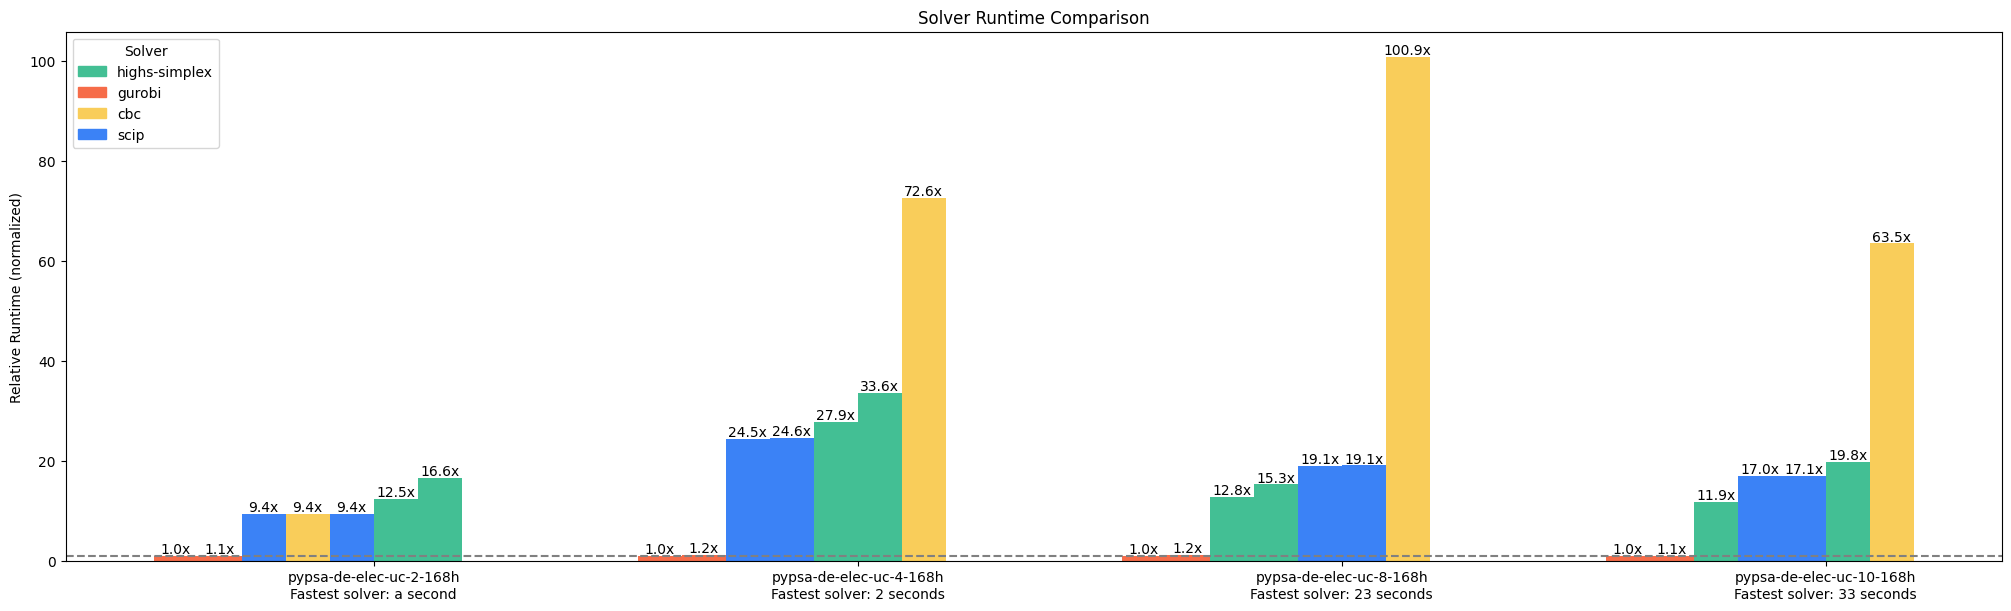

In [25]:
plot_runtime_slowdowns(results.copy(), figsize=(20, 6), max_num_solvers=10)

In [26]:
results["Runtime (s)"].max()

2363.54902716

### 20260402 Run 168h sizes 20, 50, 100

In [3]:
benchmarks_df = load_benchmark_metadata()

df = benchmarks_df[
    (benchmarks_df["Benchmark"] == "pypsa-de-elec-uc")
    & (benchmarks_df["Instance"].str.endswith("-168h"))
].copy()

df["nodes"] = df["Instance"].map(lambda i: int(i.split("-")[0]))

benchs_to_run = df[df["nodes"].isin([20, 50, 100])]

benchs_to_run["Instance"].tolist()

['20-168h', '50-168h', '100-168h']

In [4]:
# Create campaign: 1 instance per VM, latest solvers only

vm_yamls = allocate_benchmarks(
    benchs_to_run,
    "Num. variables",
    len(benchs_to_run),
    machine_type="c4-highmem-8",  # NOTE: increased to highmem!
    timeout_seconds=24 * 60 * 60,  # NOTE: 24h timeout
    solvers="gurobi highs scip cbc",  # NOTE: only running best solvers
    years=[2025, 2024],  # latest solvers only, so skip creating older conda envs
)

create_benchmark_campaign(
    "20260402-pypsa-de-elec-uc-168h-large",
    "pypsa-de-elec-uc-168h-large",
    vm_yamls,
)

Allocated. Estimated runtime: 41.5h
  VM 00: 1 instances, 41.5h
  VM 01: 1 instances, 22.8h
  VM 02: 1 instances, 10.3h
Created directory and files in ../infrastructure/benchmarks/20260402-pypsa-de-elec-uc-168h-large
Run this campaign from the infrastructure/ directory using the command:
tofu apply -var-file benchmarks/20260402-pypsa-de-elec-uc-168h-large/run.tfvars -state=states/20260402-pypsa-de-elec-uc-168h-large.tfstate


## Monitor runs

To view running VMs:
```
gcloud compute instances list | sort | tee /dev/tty | grep benchmark-instance | grep -i running | wc -l
```

To SSH into a running VM and see what's happening:
```
gcloud compute ssh projects/compute-app-427709/zones/us-central1-a/instances/benchmark-instance-more-pypsa-de-sizes-04
tail -f /var/log/startup-script.log
cat /solver-benchmark/results/benchmark_results.csv
```

In [5]:
fetch_all_partial_results()

Cleared ../results/partial-results
Error fetching instances: Command '['gcloud', 'compute', 'instances', 'list', '--filter=status:RUNNING', '--format=value(name,zone)']' returned non-zero exit status 1.
There are 0 running VMs. Fetching results from: Done.


In [6]:
check_uptimes()

Error fetching instances: Command '['gcloud', 'compute', 'instances', 'list', '--filter=status:RUNNING', '--format=value(name,zone)']' returned non-zero exit status 1.
There are 0 running instances

0 potentially hung instances:



In [9]:
partial_results, partial_variability = load_results("../results/partial-results/")
partial_results

ValueError: No objects to concatenate

## Inspect results

To download results:
```
gsutil -m rsync -r gs://solver-benchmarks/results ./results/gcp-results/
```

In [10]:
results, variability = load_results(
    ["../results/gcp-results/20260402-pypsa-de-elec-uc-168h-large/"]
)
benchmarks_df = load_benchmark_metadata()

Found 21 records, 3 benchmark instances
Dropping superceeded results from these runs: []
After dropping: 21 records, 3 benchmark instances


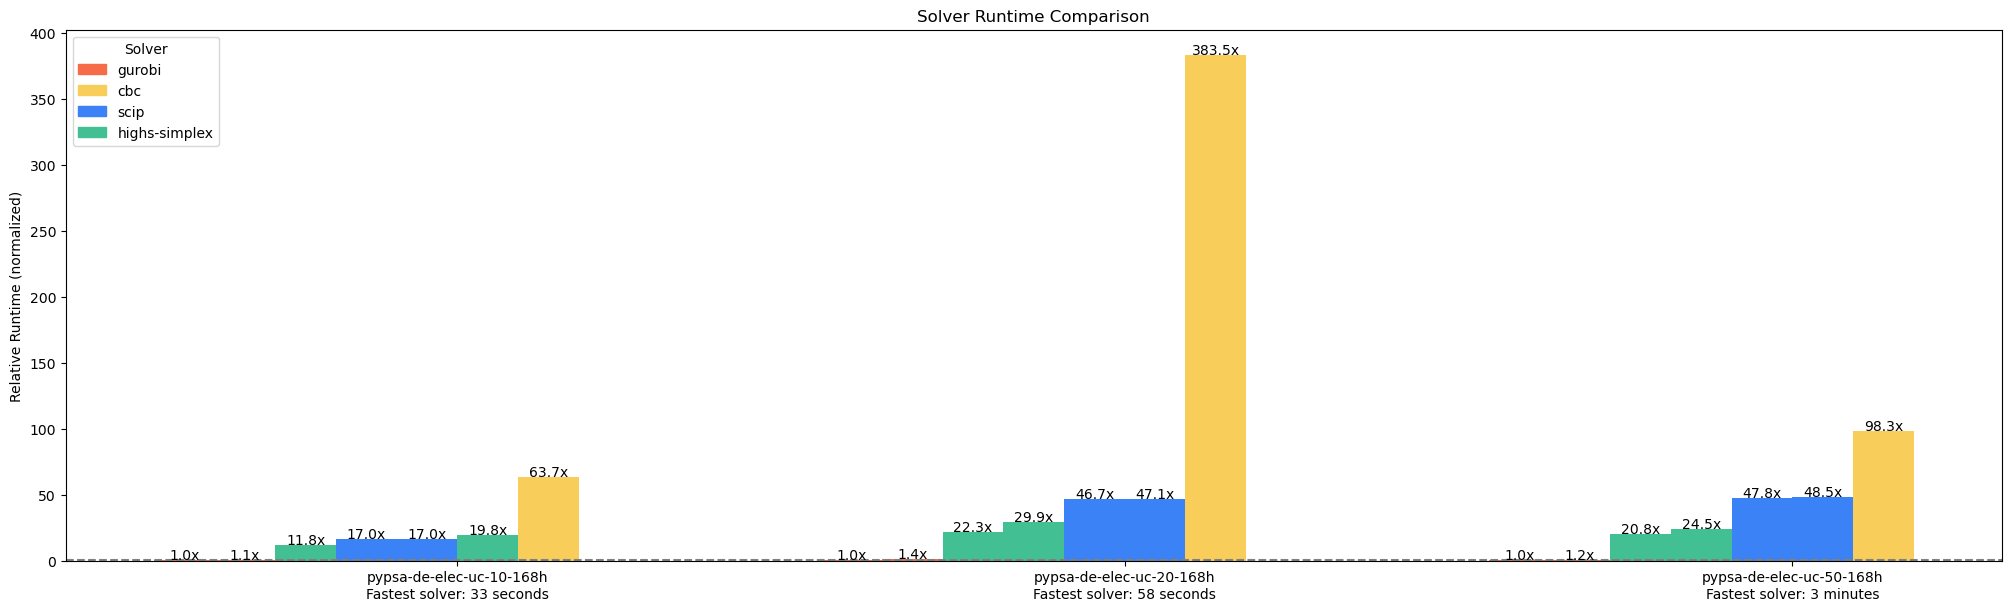

In [11]:
plot_runtime_slowdowns(results.copy(), figsize=(20, 6), max_num_solvers=10)

In [6]:
results["Runtime (s)"].max()

22529.251221874

### 20260402 Run 48h sizes 2, 4, 6, 8, 10, 20, 50

In [ ]:
benchmarks_df = load_benchmark_metadata()

df = benchmarks_df[
    (benchmarks_df["Benchmark"] == "pypsa-de-elec-uc")
    & (benchmarks_df["Instance"].str.endswith("-48h"))
].copy()

df["nodes"] = df["Instance"].map(lambda i: int(i.split("-")[0]))

benchs_to_run = df[df["nodes"].isin([2, 4, 6, 8, 10, 20, 50])]

benchs_to_run["Instance"].tolist()

In [ ]:
# Create campaign: 1 instance per VM, latest solvers only

vm_yamls = allocate_benchmarks(
    benchs_to_run,
    "Num. variables",
    len(benchs_to_run),
    machine_type="c4-highmem-8",  # NOTE: increased to highmem!
    timeout_seconds=24 * 60 * 60,  # NOTE: 24h timeout
    solvers="gurobi highs scip cbc",  # NOTE: only running best solvers
    years=[2025, 2024],  # latest solvers only, so skip creating older conda envs
)

create_benchmark_campaign(
    "20260402-pypsa-de-elec-uc-48h-large",
    "pypsa-de-elec-uc-48h-large",
    vm_yamls,
)

## Monitor runs

To view running VMs:
```
gcloud compute instances list | sort | tee /dev/tty | grep benchmark-instance | grep -i running | wc -l
```

To SSH into a running VM and see what's happening:
```
gcloud compute ssh projects/compute-app-427709/zones/us-central1-a/instances/benchmark-instance-more-pypsa-de-sizes-04
tail -f /var/log/startup-script.log
cat /solver-benchmark/results/benchmark_results.csv
```

In [ ]:
fetch_all_partial_results()

In [ ]:
check_uptimes()

In [ ]:
partial_results, partial_variability = load_results("../results/partial-results/")
partial_results

## Inspect results

To download results:
```
gsutil -m rsync -r gs://solver-benchmarks/results ./results/gcp-results/
```

In [ ]:
results, variability = load_results(
    ["../results/gcp-results/20260402-pypsa-de-elec-uc-48h/"]
)
benchmarks_df = load_benchmark_metadata()

In [ ]:
plot_runtime_slowdowns(results.copy(), figsize=(20, 6), max_num_solvers=10)

In [ ]:
results["Runtime (s)"].max()